# 30-Day Diabetes Readmission Prediction

## Project Context

This notebook develops the clinical prediction component of the **Integrated Intelligent Health Monitoring and Clinical Decision Support System**.

The goal is to predict whether a hospital encounter is associated with readmission within 30 days using the Diabetes 130-US Hospitals dataset.

The notebook uses reusable project modules rather than placing all production logic directly in the notebook:

- `src/preprocessing/diabetes.py` prepares the clinical data;
- `src/prediction/readmission.py` builds, trains, evaluates, saves, and loads the model.

A patient-aware train/test split is used so that encounters belonging to the same patient do not appear in both training and testing data.


## Modeling Strategy

The primary model is **Logistic Regression**.

This model was selected as an interpretable baseline for a healthcare decision-support setting. The target class is imbalanced, so the classifier uses balanced class weights by default.

The primary evaluation metrics are:

- **Recall** — measures how many true 30-day readmissions are detected;
- **Precision** — measures how reliable positive predictions are;
- **F1 score** — balances precision and recall;
- **ROC-AUC** — evaluates ranking performance across thresholds;
- **Accuracy** — reported for completeness but not treated as the primary metric.

The model is intended for decision support only and does not provide diagnosis or treatment recommendations.


## Setup

Import the required libraries and locate the project root.


In [49]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.20


In [50]:
cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the healthcare_capstone project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone


## Import Project Modules

Import the reusable preprocessing and modeling functions implemented in the `src` package.


In [51]:
from src.preprocessing.diabetes import (
    prepare_diabetes_data,
    preprocessing_summary,
)

from src.prediction.readmission import (
    build_readmission_pipeline,
    train_readmission_model,
    predict_readmission,
    evaluate_readmission_model,
    extract_logistic_coefficients,
    save_readmission_model,
    load_readmission_model,
    format_evaluation_metrics,
)


## Load Clinical Data

The notebook expects the UCI Diabetes dataset at:

`data/raw/diabetes/diabetic_data.csv`


In [52]:
DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "diabetes"
    / "diabetic_data.csv"
)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_FILE}"
    )

raw_df = pd.read_csv(DATA_FILE)

print("Raw dataset shape:", raw_df.shape)
raw_df.head()


Raw dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Prepare Modeling Data

The reusable preprocessing module:

- standardizes missing-value markers;
- creates the binary 30-day readmission target;
- removes extremely high-missingness features;
- removes baseline-excluded features;
- groups diagnosis codes into broader categories;
- preserves `patient_nbr` separately for grouped splitting;
- removes identifiers from the predictive feature matrix.


In [53]:
prepared = prepare_diabetes_data(raw_df)

X = prepared.X
y = prepared.y
groups = prepared.groups

preprocessing_summary(prepared)


{'rows': 101763,
 'features': 43,
 'positive_cases': 11357,
 'positive_rate_percent': 11.16,
 'unique_patients': 71515,
 'numeric_features': 8,
 'categorical_features': 35,
 'remaining_missing_values': 0}

In [54]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Unique patients:", groups.nunique())

print("\nPositive class distribution:")
print(y.value_counts())

print("\nPositive class percentage:")
print((y.value_counts(normalize=True) * 100).round(2))


Feature matrix shape: (101763, 43)
Target shape: (101763,)
Unique patients: 71515

Positive class distribution:
readmitted_30
0    90406
1    11357
Name: count, dtype: int64

Positive class percentage:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


## Feature Types

Numerical and categorical columns are identified by the preprocessing module and passed to the model pipeline.


In [55]:
print("Numerical features:")
print(prepared.numeric_columns)

print("\nCategorical features:")
print(prepared.categorical_columns)


Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']


## Patient-Aware Train/Test Split

Because some patients have multiple encounters, a standard random row-level split could place records from the same patient in both training and testing data.

`GroupShuffleSplit` uses `patient_nbr` as a grouping variable so that each patient belongs entirely to one split.


In [56]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups,
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training patients:", groups_train.nunique())
print("Testing patients:", groups_test.nunique())


Training rows: 81670
Testing rows: 20093
Training patients: 57212
Testing patients: 14303


## Verify Patient Separation

The intersection between training and testing patient identifiers should be empty.


In [57]:
patient_overlap = set(groups_train.unique()).intersection(
    set(groups_test.unique())
)

print("Patients appearing in both train and test sets:", len(patient_overlap))

assert len(patient_overlap) == 0, (
    "Patient leakage detected between training and testing data."
)


Patients appearing in both train and test sets: 0


## Compare Target Distribution Across Splits

Grouped splitting protects against patient leakage, but it does not guarantee perfectly identical class proportions. The positive-class rate is therefore checked in both sets.


In [58]:
split_distribution = pd.DataFrame({
    "training_percent": y_train.value_counts(normalize=True) * 100,
    "testing_percent": y_test.value_counts(normalize=True) * 100,
}).round(2)

split_distribution


,training_percent,testing_percent
readmitted_30,,
0,88.78,89.08
1,11.22,10.92


## Build the Modeling Pipeline

The pipeline applies preprocessing learned from the training data only.

Numerical features use:

- median imputation;
- standard scaling.

Categorical features use:

- most-frequent imputation;
- one-hot encoding with unseen categories ignored.

The classifier uses Logistic Regression with balanced class weights.


In [59]:
model = build_readmission_pipeline(
    numeric_columns=prepared.numeric_columns,
    categorical_columns=prepared.categorical_columns,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## Train the Model

Only the training subset is used when fitting the preprocessing transformations and Logistic Regression classifier.


In [60]:
model = train_readmission_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
)

print("Model training completed successfully.")


Model training completed successfully.


## Evaluate the Model

The default probability threshold is 0.50.


In [61]:
metrics = evaluate_readmission_model(
    model=model,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)

format_evaluation_metrics(metrics)


,metric,value
0,accuracy,0.668243
1,precision,0.175874
2,recall,0.552620
3,f1,0.266828
4,roc_auc,0.669378


In [62]:
print("Confusion matrix:")
print(np.array(metrics["confusion_matrix"]))

print("\nAdditional information:")
print("Threshold:", metrics["threshold"])
print("Test rows:", metrics["test_rows"])
print("Positive cases in test set:", metrics["positive_cases"])


Confusion matrix:
[[12214  5684]
 [  982  1213]]

Additional information:
Threshold: 0.5
Test rows: 20093
Positive cases in test set: 2195


## Confusion Matrix

The confusion matrix shows the balance between correctly detected readmissions, missed readmissions, correct negative predictions, and false alerts.


<Figure size 600x500 with 0 Axes>

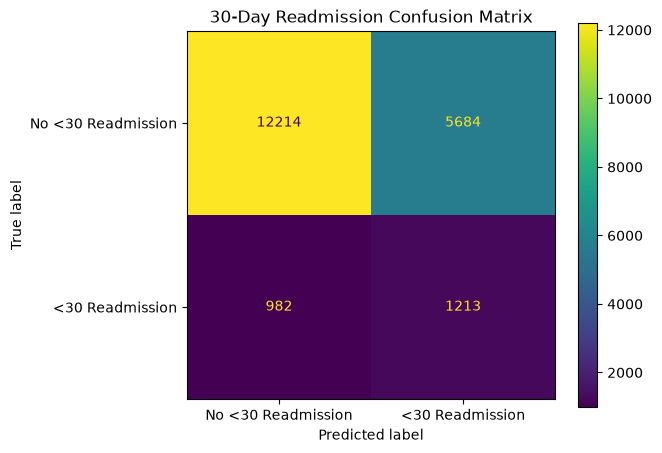

In [63]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No <30 Readmission", "<30 Readmission"],
    values_format="d",
)

plt.title("30-Day Readmission Confusion Matrix")
plt.tight_layout()
plt.show()


## ROC Curve

The ROC curve evaluates how sensitivity and false-positive rate change across decision thresholds. ROC-AUC summarizes the model's ranking ability rather than performance at only one threshold.


<Figure size 700x600 with 0 Axes>

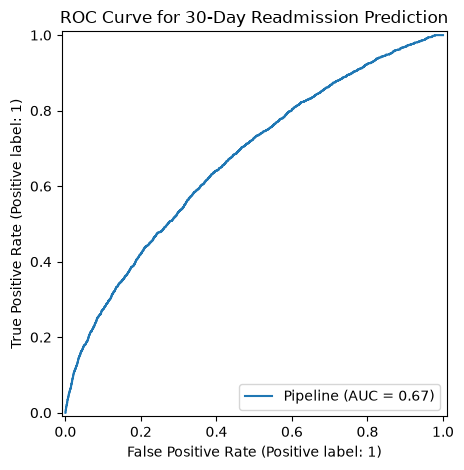

In [64]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test,
)

plt.title("ROC Curve for 30-Day Readmission Prediction")
plt.tight_layout()
plt.show()


## Prediction Examples

Generate probabilities and binary predictions for a small sample of testing encounters.


In [65]:
prediction_sample = predict_readmission(
    model=model,
    X=X_test.head(10),
    threshold=0.50,
)

prediction_sample


,readmission_probability,predicted_readmission
1,0.424927,0
7,0.437841,0
15,0.502847,1
27,0.288647,0
28,0.480499,0
30,0.289092,0
31,0.676174,1
32,0.450829,0
35,0.385705,0
39,0.361740,0


## Probability Distribution

The predicted-probability distribution helps show how confidently the model separates the two classes and whether many observations are concentrated near the decision threshold.


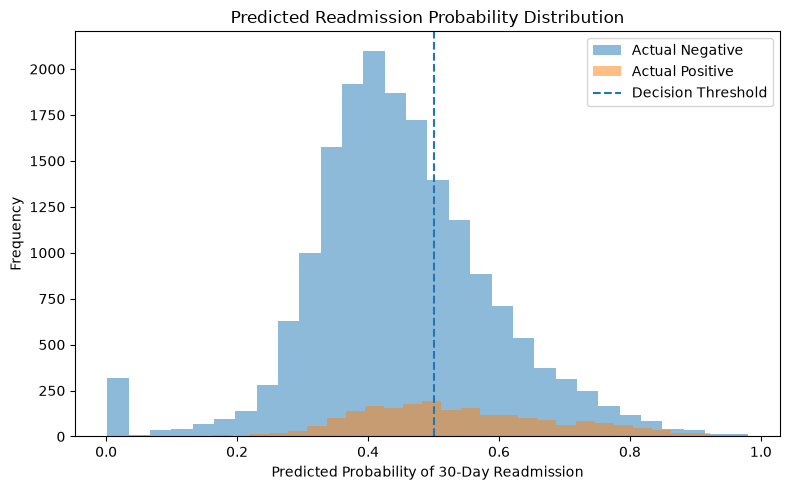

In [66]:
test_predictions = predict_readmission(
    model=model,
    X=X_test,
    threshold=0.50,
)

plt.figure(figsize=(8, 5))

plt.hist(
    test_predictions.loc[
        y_test.values == 0,
        "readmission_probability"
    ],
    bins=30,
    alpha=0.5,
    label="Actual Negative",
)

plt.hist(
    test_predictions.loc[
        y_test.values == 1,
        "readmission_probability"
    ],
    bins=30,
    alpha=0.5,
    label="Actual Positive",
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Decision Threshold",
)

plt.title("Predicted Readmission Probability Distribution")
plt.xlabel("Predicted Probability of 30-Day Readmission")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()


## Threshold Tradeoff

The classification threshold affects the balance between recall and precision.

Lower thresholds generally identify more positive cases but may create more false alerts. Higher thresholds generally reduce false positives but may miss more true readmissions.

The table below compares several thresholds without retraining the model.


In [67]:
threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_metrics = evaluate_readmission_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        threshold=threshold,
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": threshold_metrics["accuracy"],
        "precision": threshold_metrics["precision"],
        "recall": threshold_metrics["recall"],
        "f1": threshold_metrics["f1"],
        "roc_auc": threshold_metrics["roc_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.3,0.1918,0.1164,0.9708,0.2079,0.6694
1,0.4,0.4176,0.1379,0.8246,0.2362,0.6694
2,0.5,0.6682,0.1759,0.5526,0.2668,0.6694
3,0.6,0.8086,0.2322,0.3262,0.2713,0.6694
4,0.7,0.8664,0.3061,0.1759,0.2234,0.6694


## Model Interpretation

Logistic Regression coefficients provide an interpretable view of how transformed features are associated with the model's predicted readmission probability.

Positive coefficients are associated with higher predicted readmission probability and negative coefficients with lower predicted probability. These are model associations and should **not** be interpreted as causal clinical effects.


In [68]:
coefficient_df = extract_logistic_coefficients(model)

coefficient_df.head(20)


,feature,coefficient,absolute_coefficient
0,categorical__discharge_disposition_id_11,-5.072426,5.072426
1,categorical__medical_specialty_Gynecology,-1.889163,1.889163
2,categorical__discharge_disposition_id_28,1.791354,1.791354
3,categorical__discharge_disposition_id_15,1.677498,1.677498
4,categorical__discharge_disposition_id_12,1.491690,1.491690
5,categorical__medical_specialty_Pathology,-1.488048,1.488048
6,categorical__discharge_disposition_id_13,-1.365122,1.365122
7,categorical__admission_type_id_7,-1.364770,1.364770
8,categorical__medical_specialty_Pediatrics-Endo...,-1.318669,1.318669
9,categorical__discharge_disposition_id_22,1.295136,1.295136


In [69]:
top_positive = (
    coefficient_df
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_negative = (
    coefficient_df
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Features with strongest positive coefficients:")
display(top_positive[["feature", "coefficient"]])

print("\nFeatures with strongest negative coefficients:")
display(top_negative[["feature", "coefficient"]])


Features with strongest positive coefficients:


,feature,coefficient
2,categorical__discharge_disposition_id_28,1.791354
3,categorical__discharge_disposition_id_15,1.677498
4,categorical__discharge_disposition_id_12,1.491690
9,categorical__discharge_disposition_id_22,1.295136
11,categorical__medical_specialty_AllergyandImmun...,1.220838
13,categorical__discharge_disposition_id_9,1.188879
17,categorical__medical_specialty_Hematology,1.024303
18,categorical__discharge_disposition_id_5,0.995409
20,categorical__medical_specialty_Hematology/Onco...,0.952595
21,categorical__medical_specialty_Cardiology-Pedi...,0.914824



Features with strongest negative coefficients:


,feature,coefficient
0,categorical__discharge_disposition_id_11,-5.072426
1,categorical__medical_specialty_Gynecology,-1.889163
5,categorical__medical_specialty_Pathology,-1.488048
6,categorical__discharge_disposition_id_13,-1.365122
7,categorical__admission_type_id_7,-1.364770
8,categorical__medical_specialty_Pediatrics-Endo...,-1.318669
10,categorical__age_[0-10),-1.271603
12,categorical__diag_3_group_Pregnancy,-1.200887
14,categorical__medical_specialty_Pediatrics-Neur...,-1.104338
15,categorical__discharge_disposition_id_17,-1.055946


## Save the Trained Model

The complete sklearn pipeline is saved rather than only the classifier. This preserves the preprocessing transformations together with the trained model and allows the same transformations to be applied consistently during later inference.


In [70]:
MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "readmission_model.pkl"
)

saved_path = save_readmission_model(
    model=model,
    path=MODEL_PATH,
)

print("Model saved to:", saved_path)


Model saved to: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\models\readmission_model.pkl


## Verify Model Reloading

Reload the serialized pipeline and confirm that it produces the same probabilities as the in-memory model.


In [71]:
loaded_model = load_readmission_model(MODEL_PATH)

original_probs = model.predict_proba(
    X_test.head(20)
)[:, 1]

loaded_probs = loaded_model.predict_proba(
    X_test.head(20)
)[:, 1]

reload_match = np.allclose(
    original_probs,
    loaded_probs,
)

print("Reloaded predictions match:", reload_match)

assert reload_match, (
    "Reloaded model predictions do not match the original model."
)


Reloaded predictions match: True


## Save Evaluation Results

Save model metrics and coefficient information so they can be reused later in the integrated system evaluation and synthesis report.


In [72]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diabetes"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

format_evaluation_metrics(metrics).to_csv(
    OUTPUT_DIR / "readmission_model_metrics.csv",
    index=False,
)

threshold_df.to_csv(
    OUTPUT_DIR / "readmission_threshold_comparison.csv",
    index=False,
)

coefficient_df.to_csv(
    OUTPUT_DIR / "readmission_model_coefficients.csv",
    index=False,
)

print("Evaluation outputs saved to:", OUTPUT_DIR)


Evaluation outputs saved to: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\data\processed\diabetes


## Modeling Summary

This notebook establishes the first complete predictive branch of the integrated capstone system.

The workflow:

1. loads the public Diabetes 130-US Hospitals dataset;
2. applies reusable preprocessing from `src/preprocessing/diabetes.py`;
3. separates patients between training and testing data using `GroupShuffleSplit`;
4. trains a leakage-aware Logistic Regression pipeline;
5. evaluates performance using metrics appropriate for an imbalanced binary classification problem;
6. examines classification-threshold tradeoffs;
7. interprets model coefficients cautiously as associations rather than causal effects;
8. saves the complete trained pipeline for later agentic integration.

After execution, the measured Accuracy, Precision, Recall, F1 score, and ROC-AUC should be incorporated into the final synthesis paper and system evaluation.
